In [1]:
import numpy as np
import pandas as pd

In [2]:
data=pd.read_csv(r"C:\Users\rapol\Downloads\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

In [8]:
#pip install seaborn

In [10]:
data.shape

(7043, 21)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
data.duplicated().sum()

0

In [18]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')

In [20]:
data.dropna(inplace=True)

In [22]:
data.drop('customerID', axis=1, inplace=True)

In [23]:
data['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [24]:
data['Churn'].value_counts(normalize=True) * 100

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64

<Axes: xlabel='Churn', ylabel='count'>

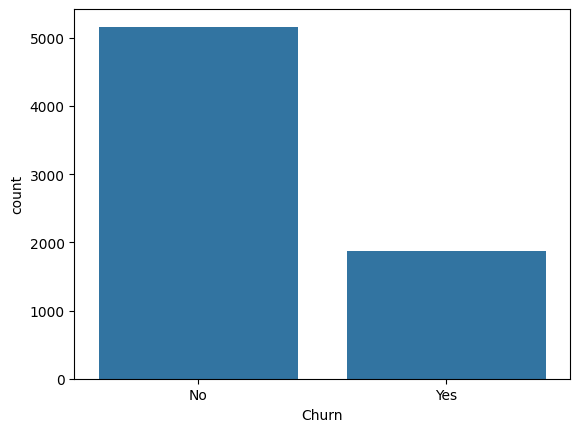

In [25]:
sns.countplot(x='Churn', data=data)

<Axes: xlabel='Contract', ylabel='count'>

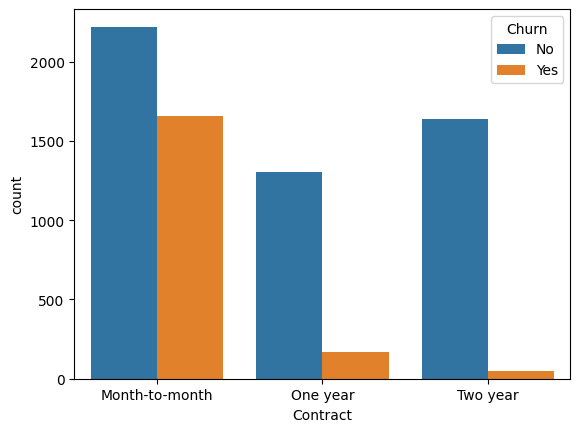

In [26]:
sns.countplot(x='Contract', hue='Churn', data=data)



<Axes: xlabel='PaymentMethod', ylabel='count'>

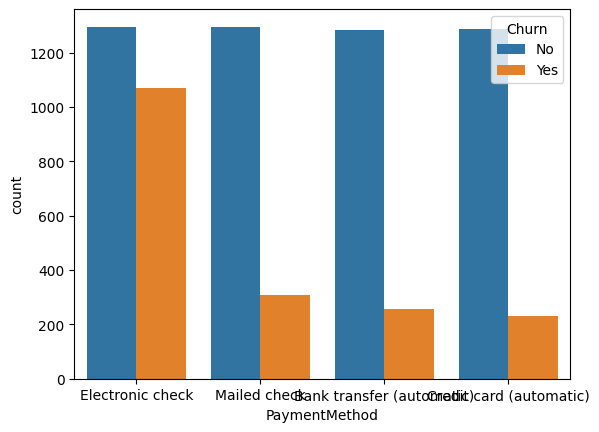

In [27]:
sns.countplot(x='PaymentMethod', hue='Churn', data=data)



<Axes: xlabel='PaymentMethod', ylabel='count'>

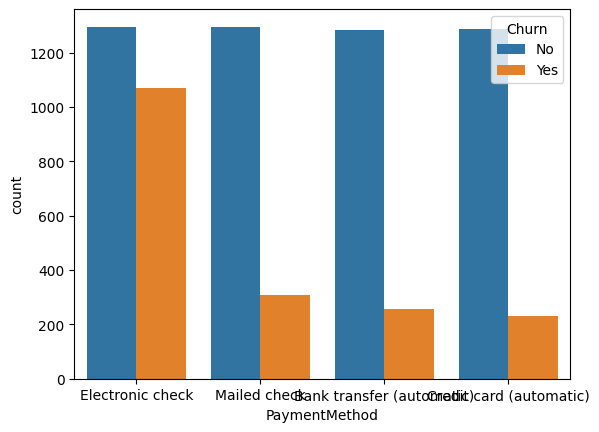

In [28]:

sns.countplot(x='PaymentMethod', hue='Churn', data=data)



<Axes: xlabel='tenure', ylabel='Count'>

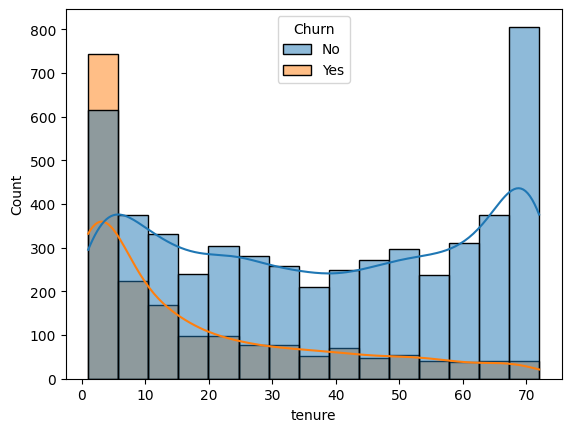

In [29]:
sns.histplot(data=data, x='tenure', hue='Churn', kde=True)

In [30]:
data_model = data.copy()

In [31]:
for col in data_model.columns:
    if data_model[col].dtype == 'object':
        le = LabelEncoder()
        data_model[col] = le.fit_transform(data_model[col])

In [35]:
x = data_model.drop('Churn', axis=1)
y = data_model['Churn']

In [36]:
x_train,x_test,y_train,y_test=train_test_split(x,y ,test_size=0.2, random_state=0)

In [37]:
model=RandomForestClassifier(n_estimators=100,random_state=42)


In [38]:
model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [40]:
y_pred=model.predict(x_test)

In [41]:
y_pred

array([0, 0, 0, ..., 1, 0, 0])

In [44]:
ac=accuracy_score(y_test,y_pred)
ac

0.7874911158493249

In [45]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1038
           1       0.62      0.49      0.55       369

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [46]:
cm = confusion_matrix(y_test, y_pred)

In [47]:
cm

array([[926, 112],
       [187, 182]], dtype=int64)

In [48]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

In [54]:
data_output=data.copy()

In [56]:
data_output['Churn_Prediction'] = model.predict(x)

In [60]:
data_output['Churn_Probability'] = model.predict_proba(x)[:, 1]

In [61]:
def risk_level(prob):
    if prob >= 0.70:
        return "High Risk"
    elif prob >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"

In [62]:
data_output['Risk_Level'] = data_output['Churn_Probability'].apply(risk_level)

In [64]:
data_output.to_csv("customer_churn_powerbi_output.csv", index=False)

In [65]:
import os
print(os.getcwd())

C:\Users\rapol
